In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/flights_2023_01.csv")

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

df.shape

C:\Users\moham\AppData\Local\Temp\ipykernel_42792\190268679.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


(538837, 21)

In [2]:
df.head()

,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,CRS_DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,...,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,LATE_AIRCRAFT_DELAY
0,2023-01-01,9E,10135,ABE,10397,ATL,600,1.0,1.0,0.0,...,-9.0,0.0,0.0,0.0,0.0,692.0,NaN,NaN,NaN,NaN
1,2023-01-01,9E,10146,ABY,10397,ATL,736,-12.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,145.0,NaN,NaN,NaN,NaN
2,2023-01-01,9E,10146,ABY,10397,ATL,1255,-10.0,0.0,0.0,...,-11.0,0.0,0.0,0.0,0.0,145.0,NaN,NaN,NaN,NaN
3,2023-01-01,9E,10185,AEX,10397,ATL,1150,425.0,425.0,1.0,...,427.0,427.0,1.0,0.0,0.0,500.0,0.0,83.0,2.0,342.0
4,2023-01-01,9E,10185,AEX,10397,ATL,1748,91.0,91.0,1.0,...,72.0,72.0,1.0,0.0,0.0,500.0,11.0,0.0,0.0,61.0


In [3]:
df.columns

Index(['FL_DATE', 'OP_UNIQUE_CARRIER', 'ORIGIN_AIRPORT_ID', 'ORIGIN',
       'DEST_AIRPORT_ID', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW',
       'DEP_DEL15', 'CRS_ARR_TIME', 'ARR_DELAY', 'ARR_DELAY_NEW', 'ARR_DEL15',
       'CANCELLED', 'DIVERTED', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
       'NAS_DELAY', 'LATE_AIRCRAFT_DELAY'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538837 entries, 0 to 538836
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   FL_DATE              538837 non-null  datetime64[ns]
 1   OP_UNIQUE_CARRIER    538837 non-null  object        
 2   ORIGIN_AIRPORT_ID    538837 non-null  int64         
 3   ORIGIN               538837 non-null  object        
 4   DEST_AIRPORT_ID      538837 non-null  int64         
 5   DEST                 538837 non-null  object        
 6   CRS_DEP_TIME         538837 non-null  int64         
 7   DEP_DELAY            528855 non-null  float64       
 8   DEP_DELAY_NEW        528855 non-null  float64       
 9   DEP_DEL15            528855 non-null  float64       
 10  CRS_ARR_TIME         538837 non-null  int64         
 11  ARR_DELAY            527197 non-null  float64       
 12  ARR_DELAY_NEW        527197 non-null  float64       
 13  ARR_DEL15     

In [5]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing

CARRIER_DELAY          422124
LATE_AIRCRAFT_DELAY    422124
NAS_DELAY              422124
WEATHER_DELAY          422124
ARR_DELAY               11640
ARR_DEL15               11640
ARR_DELAY_NEW           11640
DEP_DELAY                9982
DEP_DELAY_NEW            9982
DEP_DEL15                9982
FL_DATE                     0
ORIGIN_AIRPORT_ID           0
OP_UNIQUE_CARRIER           0
DEST_AIRPORT_ID             0
ORIGIN                      0
CRS_DEP_TIME                0
DEST                        0
CRS_ARR_TIME                0
DISTANCE                    0
CANCELLED                   0
DIVERTED                    0
dtype: int64

In [6]:
df["ARR_DEL15"].value_counts()
df["ARR_DEL15"].value_counts(normalize=True)

ARR_DEL15
0.0    0.778616
1.0    0.221384
Name: proportion, dtype: float64

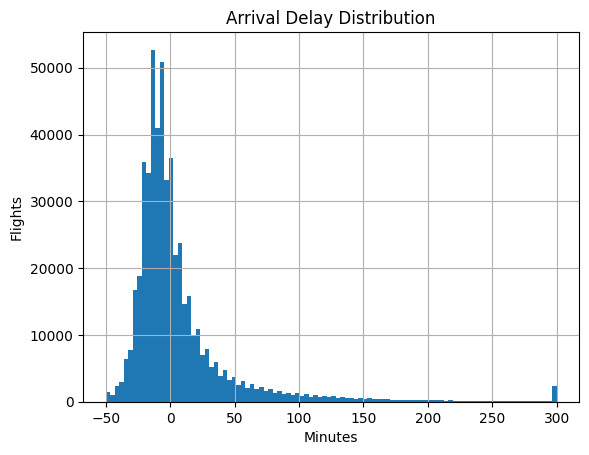

In [7]:
df["ARR_DELAY"].describe()
df["ARR_DELAY"].clip(-50,300).hist(bins=100)

plt.title("Arrival Delay Distribution")
plt.xlabel("Minutes")
plt.ylabel("Flights")

plt.show()

In [8]:
(
    df.groupby("OP_UNIQUE_CARRIER")
      ["ARR_DEL15"]
      .mean()
      .sort_values(ascending=False)
)

OP_UNIQUE_CARRIER
F9    0.351185
NK    0.290847
G4    0.284501
B6    0.264775
MQ    0.233233
UA    0.231097
OO    0.230890
AA    0.227231
HA    0.222642
9E    0.214822
AS    0.211678
DL    0.204813
WN    0.200277
YX    0.164373
OH    0.146390
Name: ARR_DEL15, dtype: float64

In [9]:
(
    df.groupby("ORIGIN")
      ["ARR_DEL15"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

ORIGIN
PPG    0.545455
CKB    0.500000
PVU    0.453333
IAG    0.444444
CMX    0.442308
JAC    0.436214
LNK    0.428571
ASE    0.425068
PSM    0.421053
PBG    0.416667
FNT    0.411392
BQN    0.402390
USA    0.400000
SHR    0.400000
EGE    0.391213
XWA    0.386364
RIW    0.379310
SWF    0.377358
SCK    0.369565
HDN    0.367052
Name: ARR_DEL15, dtype: float64

In [12]:
df["DEP_HOUR"] = (
    df["CRS_DEP_TIME"] // 100
)

In [11]:
hourly_delay = (
    df.groupby("DEP_HOUR")
      ["ARR_DEL15"]
      .mean()
)

hourly_delay

DEP_HOUR
0     0.227331
1     0.260274
2     0.262295
3     0.479167
4     0.428571
5     0.136891
6     0.137187
7     0.164995
8     0.175363
9     0.187931
10    0.194871
11    0.208656
12    0.217343
13    0.237409
14    0.240432
15    0.245652
16    0.259180
17    0.265265
18    0.272869
19    0.283722
20    0.280935
21    0.265197
22    0.253861
23    0.223316
Name: ARR_DEL15, dtype: float64

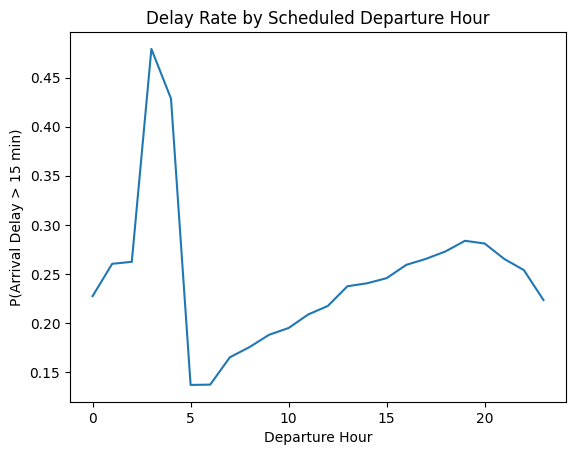

In [13]:
hourly_delay.plot()

plt.title("Delay Rate by Scheduled Departure Hour")
plt.ylabel("P(Arrival Delay > 15 min)")
plt.xlabel("Departure Hour")

plt.show()

In [14]:
(
    df.groupby("DEP_HOUR")
      ["ARR_DEL15"]
      .mean()
)

DEP_HOUR
0     0.227331
1     0.260274
2     0.262295
3     0.479167
4     0.428571
5     0.136891
6     0.137187
7     0.164995
8     0.175363
9     0.187931
10    0.194871
11    0.208656
12    0.217343
13    0.237409
14    0.240432
15    0.245652
16    0.259180
17    0.265265
18    0.272869
19    0.283722
20    0.280935
21    0.265197
22    0.253861
23    0.223316
Name: ARR_DEL15, dtype: float64

In [6]:
import pandas as pd

df = pd.read_parquet(
    "../data/features/features_2023_01.parquet"
)
df["CANCELLED"].value_counts(normalize=True)

CANCELLED
0.0    1.0
Name: proportion, dtype: float64

In [7]:
df["DIVERTED"].value_counts(normalize=True)

DIVERTED
0.0    1.0
Name: proportion, dtype: float64